In [1]:
from pathlib import Path

DATA_DIR = Path("../data")
DICTIONARY_DIR = Path("../dictionaries")

if not DATA_DIR.exists():
    DATA_DIR = Path("data")

if not DICTIONARY_DIR.exists():
    DICTIONARY_DIR = Path("dictionaries")

SAMOKAT_MAIN_PATH = DATA_DIR / "samokat_esci.csv"

DOMAIN_DICTIONARY_PATH = DICTIONARY_DIR / "domain_dictionary.txt"


# предпроцессинг

чистим запросы пользователей перед обработкой

In [2]:
import pandas as pd

df = pd.read_csv(SAMOKAT_MAIN_PATH, encoding='utf-8')

preprocessing = df.copy()
preprocessing['query'] = preprocessing['query'].str.lower().str.replace(
    r'[^\p{L}\s-]', '', regex=True
)

preprocessing['query'] = preprocessing['query'].apply(
    lambda q: ' '.join(w for w in q.split() if len(w) > 1) if pd.notna(q) else q
)


# Структура данных

| Колонка | Описание | Пример |
|---|---|---|
| query | Поисковый запрос пользователя (9 496 уникальных). Часто содержит опечатки | энергетик без сахара |
| item_name | Название товара из каталога (35 202 уникальных) | энергетик самокат, без сахара, с соком малины, 0,33 л |
| item_id | Уникальный идентификатор товара | 55e4ae6a298cf3... |
| final_answer | Оценка релевантности: E (exact – точное соответствие), S (substitute – заменитель), C (complement – дополнение), I (irrelevant – нерелевантный) | e |
| category4_name | Категория товара, уровень 4 (самый детальный) | энергетические напитки |
| category3_name | Категория товара, уровень 3 | энергетические напитки |
| category2_name | Категория товара, уровень 2 | напитки |
| category1_name | Категория товара, уровень 1 (самый общий) | безалкогольные напитки |


Всего около 9 500 уникальных запросов. К каждому запросу приставлено несколько кандидатов-товаров

In [ ]:
colorscale = [
    [0.00, "#FFFFFF"],   
    [0.01, "#FF8FA3"],  
    [0.35, "#FF3357"],
    [0.60, "#CC0024"],
    [0.80, "#99001B"],
    [1.00, "#660012"],   
]

In [49]:
import plotly.graph_objects as go
import plotly.colors as pc

order = ['e', 's', 'c', 'i']
labels_ru = {'e': 'Exact', 's': 'Substitute', 'c': 'Complement', 'i': 'Irrelevant'}
bar_colors = [pc.sample_colorscale(colorscale, [t])[0] for t in [0.55, 0.42, 0.32, 0.22]]

counts = df['final_answer'].value_counts()
values = [int(counts.get(k, 0)) for k in order]
total = sum(values)
percents = [v / total * 100 for v in values]

fig = go.Figure(go.Bar(
    x=percents,
    y=[labels_ru[k] for k in order],
    orientation='h',
    marker=dict(color=bar_colors),
    text=[f'{v:,} ({p:.1f}%)' for v, p in zip(values, percents)],
    textposition='outside',
    textfont=dict(family='system-ui, -apple-system, "Segoe UI", sans-serif', size=13, color='#0b0b0b'),
    hovertemplate='%{y}: %{text}<extra></extra>',
))

fig.update_layout(
    title=dict(
        text='Разметка датасета Самокат: E/S/C/I',
        font=dict(size=16, color='#0b0b0b'),
        x=0.02, xanchor='left',
    ),
    xaxis=dict(title='% пар запрос-товар', range=[0, max(percents) * 1.25], showgrid=False, ticksuffix='%'),
    yaxis=dict(autorange='reversed'),
    paper_bgcolor='#fcfcfb',
    plot_bgcolor='#fcfcfb',
    font=dict(family='system-ui, -apple-system, "Segoe UI", sans-serif'),
    margin=dict(l=10, r=60, t=60, b=40),
    height=350, width=800,
    showlegend=False,
)
fig.show()



In [62]:
import plotly.graph_objects as go
import plotly.colors as pc

df_plot = category_counts.sort_values(ascending=False).reset_index()
df_plot.columns = ['category1_name', 'count']

brand_colorscale = [
    [0.00, "#FFFFFF"],   
    [0.01, "#FF8FA3"],  
    [0.35, "#FF3357"],
    [0.60, "#CC0024"],
    [0.80, "#99001B"],
    [1.00, "#660012"],   
]

norm = (df_plot['count'] - df_plot['count'].min()) / (df_plot['count'].max() - df_plot['count'].min())
norm = 0.05 + 0.95 * norm

tile_colors = pc.sample_colorscale(brand_colorscale, norm.tolist())

def luminance(rgb_str):
    r, g, b = [int(v) for v in rgb_str.strip('rgb()').split(',')]
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

text_colors = ['#ffffff' if luminance(c) < 140 else '#0b0b0b' for c in tile_colors]

fig = go.Figure(go.Treemap(
    labels=df_plot['category1_name'],
    parents=[''] * len(df_plot),
    values=df_plot['count'],
    marker=dict(colors=tile_colors, line=dict(width=2, color='#fcfcfb'), pad=dict(t=6, l=3, r=3, b=3)),
    text=[f'{c:,}' for c in df_plot['count']],
    texttemplate='<b>%{label}</b><br>%{text}',
    textfont=dict(family='system-ui, -apple-system, "Segoe UI", sans-serif', size=13, color=text_colors),
    hovertemplate='<b>%{label}</b><br>запросов: %{value:,}<extra></extra>',
    tiling=dict(pad=2),
))

fig.update_layout(
    title=dict(
        text='запросы клиентов Самокат',
        font=dict(size=16, color='#0b0b0b'),
        x=0.02, xanchor='left',
    ),
    paper_bgcolor='#fcfcfb',
    font=dict(family='system-ui, -apple-system, "Segoe UI", sans-serif'),
    margin=dict(l=10, r=10, t=60, b=10),
    height=650, width=1000,
)

fig.show()

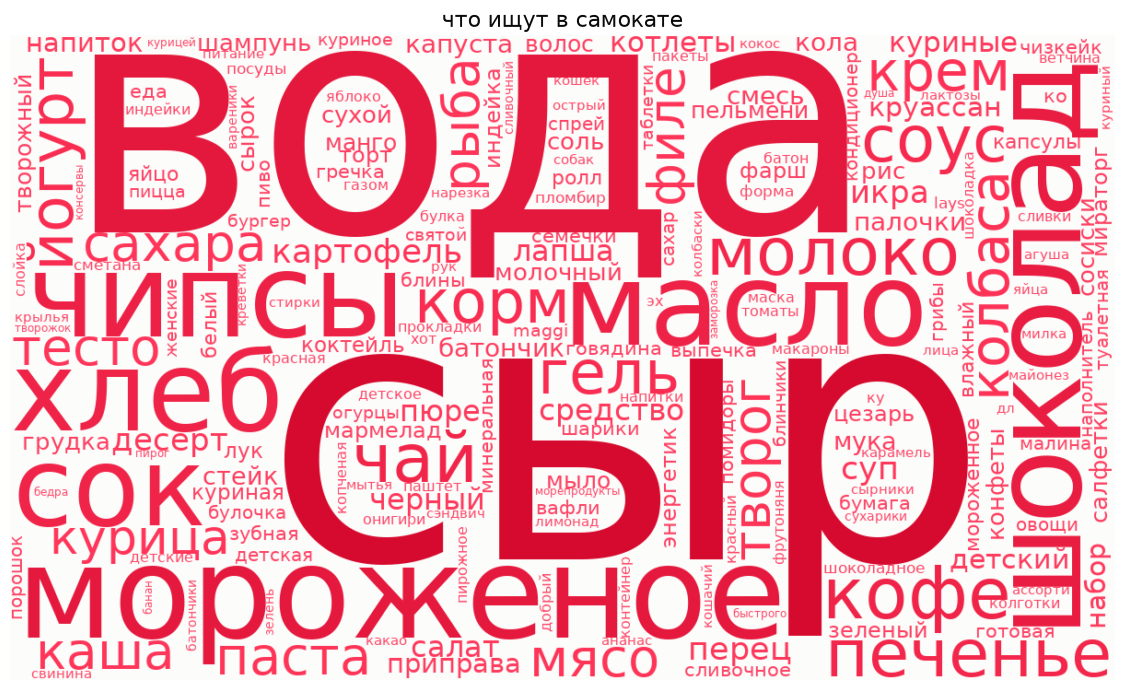

In [50]:
import os
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from wordcloud import WordCloud
import matplotlib
import matplotlib.pyplot as plt
import plotly.colors as pc
from collections import Counter

nltk.download('stopwords', quiet=True)
ru_stopwords = set(nltk_stopwords.words('russian')) | {'самокат'}

query_words = (
    preprocessing['query']
    .drop_duplicates()
    .dropna()
    .str.split()
    .explode()
)
query_words = query_words[~query_words.isin(ru_stopwords) & (query_words.str.len() >= 2)]
word_freq = Counter(query_words)

max_freq = word_freq.most_common(1)[0][1]
min_freq = min(word_freq.values())

def brand_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    t = 0.25 + 0.3 * (word_freq[word] - min_freq) / (max_freq - min_freq)
    return pc.sample_colorscale(colorscale, [t])[0]


font_path = os.path.join(os.path.dirname(matplotlib.__file__), 'mpl-data', 'fonts', 'ttf', 'DejaVuSans.ttf')

wc = WordCloud(
    width=1200, height=700,
    background_color='#fcfcfb',
    color_func=brand_color_func,
    max_words=200,
    prefer_horizontal=0.9,
    font_path=font_path,
).generate_from_frequencies(word_freq)

plt.figure(figsize=(12, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('что ищут в самокате', fontsize=16, color='#0b0b0b')
plt.tight_layout()
plt.show()


Примеры запросов и кандидатов

In [4]:
df[df['query'] == 'картофельмялка'][['query', 'item_name', 'final_answer']][0:5]

,query,item_name,final_answer
146,картофельмялка,"чеснок, 3 шт.",i
2557,картофельмялка,"варёный картофель, 500 г",c
3495,картофельмялка,"вермишель самокат на перепелиных яйцах, 300 г",i
8032,картофельмялка,"ассорти макарон самокат, детские, 250 г",i
23537,картофельмялка,"картофелемялка rondell ginger, chocolate",e


In [5]:
df[df['query'] == 'антисекс'][['query', 'item_name', 'final_answer']][0:5]

,query,item_name,final_answer
1540,антисекс,"средство дезинфицирующее самокат для рук, с ар...",i
17847,антисекс,"аэрозоль от клещей и комаров gardex baby, для ...",i
18365,антисекс,"спрей для рук haan освежающий манхэттен, очище...",i
19216,антисекс,"средство педикулицидное gardex от вшей и гнид,...",i
21493,антисекс,антисептик антисептол 5 л,i


In [6]:
df[df['query'] == 'домики для тараканов'][['query', 'item_name', 'final_answer']][0:5]

,query,item_name,final_answer
400,домики для тараканов,"ряженка домик в деревне, 2,1%, груша, 260 г",i
2996,домики для тараканов,"домик кукольный edufun с аксессуарами, 8112, 1...",i
3987,домики для тараканов,домик кукольный enchantimals бал в королевском...,i
6980,домики для тараканов,"сливочное масло домик в деревне, 72,5%, 180 г",i
8394,домики для тараканов,подсвечник домик quanzhou qingyi,i


# С какими данными мы работаем? 

https://habr.com/ru/companies/kuper/articles/826316/ - опыт купера
https://habr.com/ru/companies/sbermegamarket/articles/673614/ - опыт сбермегамаркета

Большинство запросов содержит опечатки

In [ ]:
from collections import Counter

cols = ['item_name', 'category1_name', 'category2_name', 'category3_name', 'category4_name']
cleaned_cols = [preprocessing[c].str.lower().str.replace(r'[^\p{L}\s-]', '', regex=True) for c in cols]

words = pd.concat(cleaned_cols, ignore_index=True).str.split().explode()
words = words[words.str.len() >= 2]

hyphen_parts = words[words.str.contains('-')].str.split('-').explode()
words = pd.concat([words, hyphen_parts], ignore_index=True)
words = words[words.str.len() >= 2]

dictionary = set(words.dropna())
dictionary = {w for w in dictionary if any(ch.isalpha() for ch in w)}

word_freq = Counter(words.dropna())


def is_correct(query):
    query = query.split()

    for word in query: 
        if word not in dictionary: 
            return False
    return True

preprocessing['is_correct'] = preprocessing['query'].apply(lambda q: is_correct(q))
unique_queries = preprocessing[['query', 'is_correct']].drop_duplicates(subset=['query'])

print(f"Всего уникальных запросов: {len(unique_queries['query'])}")
print(f"Из них запросов с опечатками: {len(unique_queries[unique_queries['is_correct'] == False])}")

Всего уникальных запросов: 9228
Из них запросов с опечатками: 4458


несколько примеров запросов

In [312]:
(
    preprocessing[preprocessing['is_correct'] == False][['query', 'item_name']]
    .rename(columns={'query': 'запрос', 'item_name': 'товар-кандидат'})[80:90]
)



,запрос,товар-кандидат
160,консервативные ананас,"протёртые лимон и имбирь самокат, с сахаром, 2..."
161,сордел,"шербет самокат, 2%, двухслойный, с чёрной и кр..."
162,сгушонная малако,"имбирь молотый noyer сушеный натуральный, инди..."
165,аруассаны,"круассаны 7 days мини, с ванильным кремом, 300 г"
168,сок апель,"апельсиновый сок j7 fresh taste, 0,3 л"
169,тмк батон,"батон тагилхлеб подмосковный, в нарезке, 330 г"
172,лабуба,напиток чайный vinut popping boba bubble tea m...
173,икрв,икра осетровая русское море стольная имитирова...
176,нэнер,"энергетик lit energy original, без сахара, 0,45 л"
177,лук пррей,"красный лук, 500 г"


## Типология опечаток в запросах

### 1. Недописанные / усечённые слова 
- творог мя - творог мягкий
- палочки шокола - палочки шокололадные
- протеиновы - протеиновый
- туал - туалетная
- кисломи - кисломикс
- кокт - коктейль
- мультизлаков - мультизлаковая
- пластиковая лож - пластиковая ложка
- соус майо - соус майонез
- шпина - шпинат
- шарики для сти - шарики для стирки
- круасс - круассан
- пшен - пшеннная
- газиров - газировка
- горчиц зерна - горчица зерна
- коктейль фист - коктейль фисташковый
- вода газир - вода газированная

### 2. Лишняя буква
- готовая едаз - готовая еда
- эйогурт - йогурт
- вода без газаз - вода без газа
- гранолаэ - гранола

### 3. Лишнее слово / обрывок названия бренда
- ром до - ром до
- соломка ка - соломка ка
- даниссимо ими - даниссимо ими
- же дезодоранты - же дезозоранты
- халва ку - халва ку

### 4. Перепутанные буквы
- мароконы - макароны
- пивк - пиво
- йоугор - йогурт
- ьворожный - творожный
- салëные огурец - соленый огурец
- снсиска - сосиска
- соломкс - соломка
- сгушонная малако - сгущенное молоко
- кокороз - кукуруза
- эвервеч - эвервейс
- клубникю - клубника
- лвйм - лайм
- донисоимо - даниссимо
- туалетная ьумагп - туалетная бумага
- картоыель - картофель
- оуассан - круассан
- онегирт - онигири 
- серистый творог - зернистый творог
- маршмкллов - маршмеллоу

### 5. Слипшиеся слова (нет пробела)
- бриошараматизаторь - бриошь ароматизатор
- твороженныйсвр - творожный сыр
- туалетнаябцмага - туалетная бумага
- укропбатон - укроп батон

### 6. Слово случайно разбито пробелом
- го овые - готовые
- ананаса ку сочки - ананаса кусочки

### 7. Смешанные / сложные случаи
- череизов - черкизово
- чайлипто - чай липтон
- щербетмороженное - щербет мороженное
- консервативные ананас - консервированные ананасы
- мясо индейу - мясо индейки
- перецчер - перец черный 
- чупа куё - чупа чупс
- агар агара - агар агар
- муз из манки - ???

### 8. Запросы на иностранном языке
- exponents
- nike vaprofly
- florida котят

### 9. Запросы без ошибок
- леденец на палочке петушок
- power банк беспроводной
- швабра для полов
- газировка
- малина
- корм кошачий perfect fit
- сердце желудки


# Как мы работаем с опечатками

ручная выборка 66 запросов с опечатками для проверки решения

In [23]:
typo_test_set = [

    ("творог мя", "недописанное_слово", "творог мягкий"),
    ("палочки шокола", "недописанное_слово", "палочки шоколад"),
    ("протеиновы", "недописанное_слово", "протеиновый"),
    ("туал", "недописанное_слово", "туалетная"),
    ("кисломи", "недописанное_слово", "кисломикс"),
    ("кокт", "недописанное_слово", "коктейль"),
    ("мультизлаков", "недописанное_слово", "мультизлаковая"),
    ("пластиковая лож", "недописанное_слово", "пластиковая ложка"),
    ("соус майо", "недописанное_слово", "соус майонез"),
    ("шпина", "недописанное_слово", "шпинат"),
    ("шарики для сти", "недописанное_слово", "шарики для стирки"),
    ("круасс", "недописанное_слово", "круассан"),
    ("пшен", "недописанное_слово", "пшеничное"),
    ("газиров", "недописанное_слово", "газировка"),
    ("горчиц зерна", "недописанное_слово", "горчица зерна"),
    ("коктейль фист", "недописанное_слово", "коктейль фисташковый"),
    ("икра искусств", "недописанное_слово", "икра искусственная"),

    ("готовая едаз", "лишняя_буква", "готовая еда"),
    ("эйогурт", "лишняя_буква", "йогурт"),
    ("вода без газаз", "лишняя_буква", "вода без газа"),
    ("гранолаэ", "лишняя_буква", "гранола"),

    ("ром до", "лишнее_слово_или_бренд", "ром до"),
    ("соломка ка", "лишнее_слово_или_бренд", "соломка ка"),
    ("даниссимо ими", "лишнее_слово_или_бренд", "даниссимо ими"),
    ("же дезодоранты", "лишнее_слово_или_бренд", "же дезозоранты"),
    ("халва ку", "лишнее_слово_или_бренд", "халва ку"),

    ("мароконы", "перепутаны_буквы", "макароны"),
    ("пивк", "перепутаны_буквы", "пиво"),
    ("йоугор", "перепутаны_буквы", "йогурт"),
    ("ьворожный", "перепутаны_буквы", "творожный"),
    ("салëные огурец", "перепутаны_буквы", "соленый огурец"),
    ("снсиска", "перепутаны_буквы", "сосиска"),
    ("соломкс", "перепутаны_буквы", "соломка"),
    ("сгушонная малако", "перепутаны_буквы", "сгущенное молоко"),
    ("кокороз", "перепутаны_буквы", "кукуруза"),
    ("эвервеч", "перепутаны_буквы", "эвервейс"),
    ("клубникю", "перепутаны_буквы", "клубника"),
    ("лвйм", "перепутаны_буквы", "лайм"),
    ("донисоимо", "перепутаны_буквы", "даниссимо"),
    ("туалетная ьумагп", "перепутаны_буквы", "туалетная бумага"),
    ("картоыель", "перепутаны_буквы", "картофель"),
    ("оуассан", "перепутаны_буквы", "круассан"),
    ("онегирт", "перепутаны_буквы", "онигири"),

    ("бриошараматизаторь", "слипшиеся_слова", "бриошь ароматизатор"),
    ("твороженныйсвр", "слипшиеся_слова", "творожный сыр"),
    ("туалетнаябцмага", "слипшиеся_слова", "туалетная бумага"),
    ("укропбатон", "слипшиеся_слова", "укроп батон"),

    ("го овые", "разделено_пробелом", "готовые"),
    ("ананаса ку сочки", "разделено_пробелом", "ананаса кусочки"),

    ("череизов", "сложный_случай", "черкизово"),
    ("чайлипто", "сложный_случай", "чай липтон"),
    ("щербетмороженное", "сложный_случай", "щербет мороженное"),
    ("консервативные ананас", "сложный_случай", "консервированные ананасы"),
    ("мясо индейу", "сложный_случай", "мясо индейки"),
    ("перецчер", "сложный_случай", "перец черный"),
    ("чупа куё", "сложный_случай", "чупа чупс"),
    ("агар агара", "сложный_случай", "агар агар"),
    ("муз из манки", "сложный_случай", "муз из манки"),

    ("exponents", "иностранный_язык", "exponents"),
    ("nike vaprofly", "иностранный_язык", "nike vaprofly"),
    ("florida котят", "иностранный_язык", "florida котят"),

    ("леденец на палочке петушок", "норм", "леденец на палочке петушок"),
    ("power банк беспроводной", "норм", "power банк беспроводной"),
    ("швабра для полов", "норм", "швабра для полов"),
    ("газировка", "норм", "газировка"),
    ("малина", "норм", "малина"),
    ("корм кошачий perfect fit", "норм", "корм кошачий perfect fit"),
    ("сердце желудки", "норм", "сердце желудки"),
]

typo_test_df = pd.DataFrame(typo_test_set, columns=['query', 'error_type', 'expected'])
typo_test_df.to_csv('typo_test_set.csv', index=False, encoding='utf-8')


In [63]:
def evaluate_typos(corrected_queries, test_df=typo_test_df):
    
    result = test_df.copy()
    result['corrected'] = list(corrected_queries)

    has_gold = result['expected'].notna()
    result['is_match'] = pd.NA
    result.loc[has_gold, 'is_match'] = (
        result.loc[has_gold, 'corrected'].apply(lemmatize_text)
        == result.loc[has_gold, 'expected'].apply(lemmatize_text)
    )

    accuracy = result.loc[has_gold, 'is_match'].mean()
    accuracy_by_type = (
        result[has_gold].groupby('error_type')['is_match'].mean().sort_values()
    )

    print(f"точность: {accuracy:.1%} (по {has_gold.sum()} размеченным примерам)")
    print(accuracy_by_type)
    print()
    print(result[result['is_match'] == False][['query', 'error_type', 'expected', 'corrected']].to_string(index=False))

    return result, accuracy, accuracy_by_type


Подход 1: чистый symspellpy

In [51]:
import marisa_trie
from symspellpy import SymSpell, Verbosity

sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
sym_spell.load_dictionary(DOMAIN_DICTIONARY_PATH, 0, 1, separator=' ', encoding='utf-8')

trie = marisa_trie.Trie(dictionary)

DISTANCE_PENALTY = 10


def correct_word(word, max_edit_distance=2):
    if word in dictionary:
        return word

    candidates = sym_spell.lookup(word, Verbosity.ALL, max_edit_distance=max_edit_distance)
    if candidates:
        best = max(candidates, key=lambda s: s.count / (DISTANCE_PENALTY ** s.distance))
        return best.term

    segmentation = sym_spell.word_segmentation(word, max_edit_distance=max_edit_distance)
    parts = segmentation.corrected_string.split()
    if (
        len(parts) > 1
        and all(p in dictionary for p in parts)
        and segmentation.distance_sum <= max_edit_distance
        and all(word_freq.get(p, 0) >= 3 for p in parts)
    ):
        return segmentation.corrected_string

    return word


def correct_query(query, max_edit_distance=2):
    query = query.strip()
    words = query.split()
    return ' '.join(correct_word(w, max_edit_distance) for w in words)


In [52]:
corrected_1 = typo_test_df['query'].apply(lambda q: correct_query(q))
report_1, acc_1, by_type_1 = evaluate_typos(corrected_1)

точность (по леммам): 52.9% (по 68 размеченным примерам)
error_type
разделено_пробелом             0.0
сложный_случай            0.222222
слипшиеся_слова               0.25
недописанное_слово        0.352941
лишнее_слово_или_бренд         0.6
иностранный_язык          0.666667
перепутаны_буквы          0.705882
лишняя_буква                  0.75
норм                           1.0
Name: is_match, dtype: object

                query             error_type                 expected             corrected
            творог мя     недописанное_слово            творог мягкий           творог мясо
                 туал     недописанное_слово                туалетная                  тела
              кисломи     недописанное_слово                кисломикс             кислотами
                 кокт     недописанное_слово                 коктейль                   кот
      пластиковая лож     недописанное_слово        пластиковая ложка      пластиковая кожи
            соус майо     недописа

Подход 2: symspellpy + prefix

In [57]:
import marisa_trie
from symspellpy import SymSpell, Verbosity

sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
sym_spell.load_dictionary(DOMAIN_DICTIONARY_PATH, 0, 1, separator=' ', encoding='utf-8')

trie = marisa_trie.Trie(dictionary)

DISTANCE_PENALTY = 10


def correct_word_prefix(word, max_edit_distance=2):
    if word in dictionary:
        return word

    if len(word) >= 2:
        completions = trie.keys(word)
        if completions:
            return max(completions, key=lambda w: word_freq.get(w, 0))

    candidates = sym_spell.lookup(word, Verbosity.ALL, max_edit_distance=max_edit_distance)
    if candidates:
        best = max(candidates, key=lambda s: s.count / (DISTANCE_PENALTY ** s.distance))
        return best.term

    segmentation = sym_spell.word_segmentation(word, max_edit_distance=max_edit_distance)
    parts = segmentation.corrected_string.split()
    if (
        len(parts) > 1
        and all(p in dictionary for p in parts)
        and segmentation.distance_sum <= max_edit_distance
        and all(word_freq.get(p, 0) >= 3 for p in parts)
    ):
        return segmentation.corrected_string

    return word


def correct_query_prefix(query, max_edit_distance=2):
    query = query.strip()
    words = query.split()
    return ' '.join(correct_word_prefix(w, max_edit_distance) for w in words)


In [58]:
corrected_2 = typo_test_df['query'].apply(lambda q: correct_query_prefix(q))
report_2, acc_2, by_type_2 = evaluate_typos(corrected_2)

точность (по леммам): 63.2% (по 68 размеченным примерам)
error_type
разделено_пробелом             0.0
сложный_случай            0.222222
слипшиеся_слова               0.25
лишнее_слово_или_бренд         0.6
иностранный_язык          0.666667
перепутаны_буквы          0.705882
лишняя_буква                  0.75
недописанное_слово        0.764706
норм                           1.0
Name: is_match, dtype: object

                query             error_type                 expected               corrected
            творог мя     недописанное_слово            творог мягкий             творог мясо
              газиров     недописанное_слово                газировка            газированная
        коктейль фист     недописанное_слово     коктейль фисташковый       коктейль фисташки
        икра искусств     недописанное_слово       икра искусственная           икра искусств
         готовая едаз           лишняя_буква              готовая еда            готовая глаз
        даниссимо ими 

Подход 2: sage-fred5-distiled

Подход 3: дообучение своей модели

Выводы

In [59]:
es_queries = preprocessing[preprocessing['final_answer'].isin(['e', 's'])]
es_queries = es_queries.dropna(subset='category1_name')


In [60]:
es_queries = preprocessing[preprocessing['final_answer'].isin(['e', 's'])]
es_queries = es_queries.dropna(subset='category1_name')

query_category_nunique = es_queries.groupby('query')['category1_name'].nunique()

unambiguous_queries = query_category_nunique[query_category_nunique == 1].index
es_queries = es_queries[es_queries['query'].isin(unambiguous_queries)]

category_counts = es_queries.groupby('category1_name')['query'].nunique()

# Кластеризация запросов

Для векторизации мы будем использовать: e5-small, sbert_large_nlu, bge-m3

In [65]:
import umap
from sentence_transformers import SentenceTransformer
from sklearn.cluster import HDBSCAN



/opt/anaconda3/envs/study/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [66]:
e5_model = SentenceTransformer('d0rj/e5-small-en-ru')

In [ ]:
path = "/Users/mishanya/Desktop/models/sbert_large_nlu_ru"
sbert_model = SentenceTransformer(path, device='mps')

# здесь bge-m3

KeyboardInterrupt: 

In [ ]:
reducer = umap.UMAP(random_state=228, n_components=15, metric='cosine', n_neighbors=10, min_dist=0.0,)
clusterer = HDBSCAN(min_cluster_size=20, min_samples=15)

готовим эмбеддинги

In [ ]:
es_queries = preprocessing[preprocessing['final_answer'].isin(['e', 'c'])]
es_queries = es_queries.dropna(subset='category1_name')

query_category_nunique = es_queries.groupby('query')['category1_name'].nunique()
queries = query_category_nunique[query_category_nunique == 1].index.to_list()

In [ ]:
queries_prefixed = [f"query: {q}" for q in queries] # необходимо, чтобы e5 работал корректно

e5_embeddings = e5_model.encode(queries_prefixed, convert_to_numpy=True, show_progress_bar=True)
print(f'Ембеддинги e5: {e5_embeddings.shape}')


Batches:   0%|          | 0/145 [00:00<?, ?it/s]

Ембеддинги e5: (4622, 384)


In [ ]:
sbert_embeddings = sbert_model.encode(queries, convert_to_numpy=True, show_progress_bar=True)
print(f'eмбеддинги sbert: {sbert_embeddings.shape}')

In [ ]:
# bge_embeddings = ...
# print(f'')

In [140]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

query_to_category = es_queries.drop_duplicates(subset=['query']).set_index('query')['category1_name']

encoder = LabelEncoder()
encoder.fit(query_to_category.unique())

category1_labels = np.array([
    encoder.transform([query_to_category[q]])[0] if q in query_to_category.index else -1
    for q in queries
])


In [141]:
X_reduced_e5 = reducer.fit_transform(e5_embeddings)

clustered_e5 = clusterer.fit_predict(X_reduced_e5)

n_clusters_e5 = len(set(clustered_e5))
n_noise_e5 = (clustered_e5 == -1).sum()

clustered_df_e5 = pd.DataFrame({'query': queries, 'cluster': clustered_e5})

/opt/anaconda3/envs/study/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


нужно перед этим еще просто спроецировать эмбеддинги

In [153]:
import plotly.graph_objects as go
import numpy as np

viz_reducer_3d = umap.UMAP(n_components=3, metric='cosine', random_state=228)
X_viz_3d = viz_reducer_3d.fit_transform(e5_embeddings)

queries_arr = np.array(queries)

palette = ['#2a78d6', '#1baf7a', '#eda100', '#008300',
           '#4a3aa7', '#e34948', '#e87ba4', '#eb6834']

named_clusters = {
    5: 'мороженое',
    12: 'сыр',
    120: 'иностранные запросы',
    25: 'чистящие средства',
    71: 'шоколад',
    3: 'чипсы',
    23: 'курица',
    26: 'хлеб',
}
top_clusters = list(named_clusters.keys())

fig = go.Figure()

noise_mask = clustered_e5 == -1
fig.add_trace(go.Scatter3d(
    x=X_viz_3d[noise_mask, 0], y=X_viz_3d[noise_mask, 1], z=X_viz_3d[noise_mask, 2],
    mode='markers', marker=dict(size=2, color='#c3c2b7', opacity=0.3),
    text=queries_arr[noise_mask], hovertemplate='%{text}<extra></extra>',
    name='шум'
))

other_mask = ~noise_mask & ~np.isin(clustered_e5, top_clusters)
if other_mask.any():
    fig.add_trace(go.Scatter3d(
        x=X_viz_3d[other_mask, 0], y=X_viz_3d[other_mask, 1], z=X_viz_3d[other_mask, 2],
        mode='markers', marker=dict(size=2.5, color='#898781', opacity=0.5),
        text=queries_arr[other_mask], hovertemplate='%{text}<extra></extra>',
        name='другое'
    ))

for color, c in zip(palette, top_clusters):
    mask = clustered_e5 == c
    fig.add_trace(go.Scatter3d(
        x=X_viz_3d[mask, 0], y=X_viz_3d[mask, 1], z=X_viz_3d[mask, 2],
        mode='markers', marker=dict(size=3.5, color=color, opacity=0.85),
        text=queries_arr[mask], hovertemplate='%{text}<extra></extra>',
        name=named_clusters[c]
    ))

fig.update_layout(
    title='кластеры запросов',
    scene=dict(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False),
    width=900, height=750,
    legend=dict(x=1.02, y=0.5)
)
fig.show()


/opt/anaconda3/envs/study/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [68]:
clustered_df_e5[clustered_df_e5['cluster'] == 6]

NameError: name 'clustered_df_e5' is not defined

In [148]:
import pymorphy3
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

nltk.download('stopwords')

morph = pymorphy3.MorphAnalyzer()

stopwords = stopwords.words('russian')
stopwords_lemmatized = list(set(morph.parse(w)[0].normal_form for w in stopwords))

morph = pymorphy3.MorphAnalyzer()

def lemmatize(text):
    return ' '.join(morph.parse(word)[0].normal_form for word in text.split())

queries_by_cluster = clustered_df_e5.groupby('cluster')['query'].apply(lambda x: x.str.cat(sep = ' '))
documents_lemmatized = queries_by_cluster.apply(lemmatize)

vectorizer = TfidfVectorizer(stop_words=stopwords_lemmatized)

tfidf_matrix = vectorizer.fit_transform(documents_lemmatized)

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=documents_lemmatized.index,
)

N_TOP_WORDS = 2

top_words = {
    cluster: df_tfidf.loc[cluster].sort_values(ascending=False).head(N_TOP_WORDS).index.tolist()
    for cluster in df_tfidf.index
}

cluster_names = {
    cluster: ' / '.join(words)
    for cluster, words in top_words.items()
}

clustered_df_e5['cluster_name'] = clustered_df_e5['cluster'].map(cluster_names).fillna('шум')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mishanya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [149]:
import plotly.graph_objects as go
import plotly.colors as pc

df_plot = (
    clustered_df_e5[clustered_df_e5['cluster'] != -1]
    .groupby('cluster_name')['query']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)
df_plot.columns = ['cluster_name', 'count']

brand_colorscale = [
    [0.00, "#FFFFFF"],
    [0.01, "#FF8FA3"],
    [0.35, "#FF3357"],
    [0.60, "#CC0024"],
    [0.80, "#99001B"],
    [1.00, "#660012"],
]

norm = (df_plot['count'] - df_plot['count'].min()) / (df_plot['count'].max() - df_plot['count'].min())
norm = 0.05 + 0.95 * norm

tile_colors = pc.sample_colorscale(brand_colorscale, norm.tolist())

def luminance(rgb_str):
    r, g, b = [int(v) for v in rgb_str.strip('rgb()').split(',')]
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

text_colors = ['#ffffff' if luminance(c) < 140 else '#0b0b0b' for c in tile_colors]

fig = go.Figure(go.Treemap(
    labels=df_plot['cluster_name'],
    parents=[''] * len(df_plot),
    values=df_plot['count'],
    marker=dict(colors=tile_colors, line=dict(width=2, color='#fcfcfb'), pad=dict(t=6, l=3, r=3, b=3)),
    text=[f'{c:,}' for c in df_plot['count']],
    texttemplate='<b>%{label}</b><br>%{text}',
    textfont=dict(family='system-ui, -apple-system, "Segoe UI", sans-serif', size=13, color=text_colors),
    hovertemplate='<b>%{label}</b><br>запросов: %{value:,}<extra></extra>',
    tiling=dict(pad=2),
))

fig.update_layout(
    title=dict(
        text=f'запросы пользователей Самокат: {len(df_plot)} категорий',
        font=dict(size=16, color='#0b0b0b'),
        x=0.02, xanchor='left',
    ),
    paper_bgcolor='#fcfcfb',
    font=dict(family='system-ui, -apple-system, "Segoe UI", sans-serif'),
    margin=dict(l=10, r=10, t=60, b=10),
    height=650, width=1000,
)

fig.show()


плохие запросы

In [107]:
bad_queries = preprocessing[~preprocessing['query'].isin(es_queries['query'])]
bad_queries_unique = bad_queries['query'].drop_duplicates().to_list()

embeddings_e5_bad = e5_model.encode(bad_queries_unique, convert_to_numpy=True, show_progress_bar=True)
print(f'эмбеддинги плохих запросов: {embeddings_e5_bad.shape}')



Batches:   0%|          | 0/94 [00:00<?, ?it/s]

эмбеддинги плохих запросов: (3003, 384)


In [108]:
reducer_bad = umap.UMAP(n_components=15, metric='cosine', n_neighbors=10, min_dist=0.0, random_state=42)
clusterer_bad = HDBSCAN(min_cluster_size=15, min_samples=10)

X_reduced_bad = reducer_bad.fit_transform(embeddings_e5_bad)
clustered_bad = clusterer_bad.fit_predict(X_reduced_bad)

n_clusters_bad = len(set(clustered_bad)) - (1 if -1 in clustered_bad else 0)
n_noise_bad = (clustered_bad == -1).sum()

clustered_df_bad = pd.DataFrame({'query': bad_queries_unique, 'cluster': clustered_bad})
print(f"Кластеров: {n_clusters_bad}, шум: {n_noise_bad}")


/opt/anaconda3/envs/study/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Кластеров: 53, шум: 1124


In [110]:
queries_by_cluster_bad = clustered_df_bad.groupby('cluster')['query'].apply(lambda x: x.str.cat(sep=' '))
documents_lemmatized_bad = queries_by_cluster_bad.apply(lemmatize)

vectorizer_bad = TfidfVectorizer(stop_words=stopwords_lemmatized)
tfidf_matrix_bad = vectorizer_bad.fit_transform(documents_lemmatized_bad)

df_tfidf_bad = pd.DataFrame(
    tfidf_matrix_bad.toarray(),
    columns=vectorizer_bad.get_feature_names_out(),
    index=documents_lemmatized_bad.index,
)

N_TOP_WORDS = 2
top_words_bad = {
    cluster: df_tfidf_bad.loc[cluster].sort_values(ascending=False).head(N_TOP_WORDS).index.tolist()
    for cluster in df_tfidf_bad.index
}
cluster_names_bad = {cluster: ' / '.join(words) for cluster, words in top_words_bad.items()}

clustered_df_bad['cluster_name'] = clustered_df_bad['cluster'].map(cluster_names_bad).fillna('шум')


In [111]:
viz_reducer_3d_bad = umap.UMAP(n_components=3, metric='cosine', random_state=42)
X_viz_3d_bad = viz_reducer_3d_bad.fit_transform(embeddings_e5_bad)

queries_arr_bad = np.array(bad_queries_unique)

cluster_sizes_bad = clustered_df_bad[clustered_df_bad['cluster'] != -1]['cluster'].value_counts()
top_clusters_bad = cluster_sizes_bad.head(8).index.tolist()

fig = go.Figure()

noise_mask = clustered_bad == -1
fig.add_trace(go.Scatter3d(
    x=X_viz_3d_bad[noise_mask, 0], y=X_viz_3d_bad[noise_mask, 1], z=X_viz_3d_bad[noise_mask, 2],
    mode='markers', marker=dict(size=2, color='#c3c2b7', opacity=0.3),
    text=queries_arr_bad[noise_mask], hovertemplate='%{text}<extra></extra>',
    name='шум'
))

other_mask = ~noise_mask & ~np.isin(clustered_bad, top_clusters_bad)
if other_mask.any():
    fig.add_trace(go.Scatter3d(
        x=X_viz_3d_bad[other_mask, 0], y=X_viz_3d_bad[other_mask, 1], z=X_viz_3d_bad[other_mask, 2],
        mode='markers', marker=dict(size=2.5, color='#898781', opacity=0.5),
        text=queries_arr_bad[other_mask], hovertemplate='%{text}<extra></extra>',
        name='другое'
    ))

for color, c in zip(palette, top_clusters_bad):
    mask = clustered_bad == c
    fig.add_trace(go.Scatter3d(
        x=X_viz_3d_bad[mask, 0], y=X_viz_3d_bad[mask, 1], z=X_viz_3d_bad[mask, 2],
        mode='markers', marker=dict(size=3.5, color=color, opacity=0.85),
        text=queries_arr_bad[mask], hovertemplate='%{text}<extra></extra>',
        name=cluster_names_bad.get(c, str(c))
    ))

fig.update_layout(
    title='кластеры "плохих" запросов',
    scene=dict(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False),
    width=900, height=750,
    legend=dict(x=1.02, y=0.5)
)
fig.show()


/opt/anaconda3/envs/study/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [112]:
N_EXAMPLES = 6

examples_table_bad = (
    clustered_df_bad[clustered_df_bad['cluster'].isin(top_clusters_bad)]
    .assign(name=lambda d: d['cluster'].map(cluster_names_bad))
    .groupby('name')
    .agg(
        size=('query', 'count'),
        examples=('query', lambda x: ', '.join(x.sample(min(N_EXAMPLES, len(x)), random_state=42))),
    )
    .sort_values('size', ascending=False)
)

examples_table_bad


,size,examples
name,,
dew / sweet,229,"tiki, challah, fere, detox , borelli, bring"
курица / куриный,113,"колбаска для гриля, семена подсолнечника очища..."
майонез / монтидь,90,"мономах, булдаг, мон блю, канилони, маскулан, ..."
шоколад / молоко,75,"рошенконфеты, конфетки ба, квадратики шоколад ..."
чай / яйцо,65,"мед малина, малина в шоколадом, сок л, сок я..."
вихотка / вегетка,48,"попрщок, паниро, панпер, перевязок, вкник, поавле"
стекло / стеклянный,47,"в поездку, для уни, для холодильник, для мочи,..."
изжога / ожог,45,"гипноза, все горох, пластырь от ожога, угли из..."


Sbert

In [12]:
sbert_embeddings = sbert_model.encode(queries_prefixed, convert_to_numpy=True, show_progress_bar=True)

Batches:   0%|          | 0/164 [00:00<?, ?it/s]

In [72]:
X_reduced_sbert = reducer.fit_transform(sbert_embeddings)

clustered_sbert = clusterer.fit_predict(X_reduced_sbert, y=category1_labels)

clustered_df_sbert = pd.DataFrame({'query': queries, 'cluster': clustered_sbert})

/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [73]:
n_clusters_sbert = len(set(clustered_sbert))
n_noise_sbert = (clustered_sbert == -1).sum()

In [74]:
import pymorphy3
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

morph = pymorphy3.MorphAnalyzer()
nltk.download('stopwords')

stopwords = stopwords.words('russian')
stopwords_lemmatized = list(set(morph.parse(w)[0].normal_form for w in stopwords))

def lemmatize(text):
    return ' '.join(morph.parse(word)[0].normal_form for word in text.split())

queries_by_cluster_sbert = clustered_df_sbert.groupby('cluster')['query'].apply(lambda x: x.str.cat(sep = ' '))
documents_lemmatized_sbert = queries_by_cluster_sbert.apply(lemmatize)

vectorizer = TfidfVectorizer(stop_words=stopwords_lemmatized)

tfidf_matrix = vectorizer.fit_transform(documents_lemmatized_sbert)

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=documents_lemmatized_sbert.index,
)

N_TOP_WORDS = 2

top_words = {
    cluster: df_tfidf.loc[cluster].sort_values(ascending=False).head(N_TOP_WORDS).index.tolist()
    for cluster in df_tfidf.index
}

cluster_names_sbert = {
    cluster: ' / '.join(words)
    for cluster, words in top_words.items()
}

clustered_df_sbert['cluster_name'] = clustered_df_sbert['cluster'].map(cluster_names).fillna('шум')

[nltk_data] Error loading stopwords: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>


In [45]:
N_EXAMPLES = 6

examples_table_sbert = (
    clustered_df_sbert[clustered_df_sbert['cluster'].isin(top_clusters_sbert)]
    .assign(name=lambda d: d['cluster'].map(cluster_names_sbert))
    .groupby('name')
    .agg(
        size=('query', 'count'),
        examples=('query', lambda x: ', '.join(x.sample(min(N_EXAMPLES, len(x)), random_state=42))),
    )
    .sort_values('size', ascending=False)
)

examples_table_sbert

NameError: name 'cluster_names_sbert' is not defined

это ближе 

In [112]:
clustered_df_sbert[clustered_df_sbert['cluster'] == 45]

,query,cluster,cluster_name
991,глазированные сырки со сгущенкой,45,творожный / сырок
1520,йогурт густой йогурт и творожки,45,творожный / сырок
2736,мусс творожный,45,творожный / сырок
3826,снежок кисломолочный,45,творожный / сырок
4200,сыр творож,45,творожный / сырок
4201,сыр твороженый,45,творожный / сырок
4202,сыр творожный,45,творожный / сырок
4203,сыр творожный сливочнвй,45,творожный / сырок
4211,сыр шоколад,45,творожный / сырок
4241,сырок со сгущенкой,45,творожный / сырок


мб имеет смысл убрать самокат как стопслово. на примере 5 кластера видно

In [36]:
import numpy as np

In [77]:
import plotly.graph_objects as go
import plotly.colors as pc

viz_reducer_3d_sbert = umap.UMAP(n_components=3, metric='cosine', random_state=42)
X_viz_3d_sbert = viz_reducer_3d_sbert.fit_transform(sbert_embeddings)

queries_arr_sbert = np.array(queries)

palette = ['#2a78d6', '#1baf7a', '#eda100', '#008300',
           '#4a3aa7', '#e34948', '#e87ba4', '#eb6834']


cluster_sizes_sbert = clustered_df_sbert[clustered_df_sbert['cluster'] != -1]['cluster'].value_counts()
top_clusters_sbert = cluster_sizes_sbert.head(8).index.tolist()

fig = go.Figure()

noise_mask = clustered_sbert == -1
fig.add_trace(go.Scatter3d(
    x=X_viz_3d_sbert[noise_mask, 0], y=X_viz_3d_sbert[noise_mask, 1], z=X_viz_3d_sbert[noise_mask, 2],
    mode='markers', marker=dict(size=2, color='#c3c2b7', opacity=0.3),
    text=queries_arr_sbert[noise_mask], hovertemplate='%{text}<extra></extra>',
    name='шум'
))

other_mask = ~noise_mask & ~np.isin(clustered_sbert, top_clusters_sbert)
if other_mask.any():
    fig.add_trace(go.Scatter3d(
        x=X_viz_3d_sbert[other_mask, 0], y=X_viz_3d_sbert[other_mask, 1], z=X_viz_3d_sbert[other_mask, 2],
        mode='markers', marker=dict(size=2.5, color='#898781', opacity=0.5),
        text=queries_arr_sbert[other_mask], hovertemplate='%{text}<extra></extra>',
        name='другое'
    ))

for color, c in zip(palette, top_clusters_sbert):
    mask = clustered_sbert == c
    fig.add_trace(go.Scatter3d(
        x=X_viz_3d_sbert[mask, 0], y=X_viz_3d_sbert[mask, 1], z=X_viz_3d_sbert[mask, 2],
        mode='markers', marker=dict(size=3.5, color=color, opacity=0.85),
        text=queries_arr_sbert[mask], hovertemplate='%{text}<extra></extra>',
        name=cluster_names_sbert.get(c, str(c))
    ))

fig.update_layout(
    title='кластеры запросов sbert',
    scene=dict(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False),
    width=900, height=750,
    legend=dict(x=1.02, y=0.5)
)
fig.show()



/opt/anaconda3/envs/study/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


дообучить берт для классификации запросов